# Modelo Final — LightGBM Fase B (feature engineering relacional)

**Objetivo:** superar el modelo de Fase A (ROC-AUC 0.7561) incorporando las
79 features construidas desde las 5 tablas secundarias.

**Referencia Fase A:**
- ROC-AUC: 0.7561
- Recall:   0.6602
- Features: 72 (solo tabla principal)

**Fase B agrega:**
- bureau + bureau_balance: 17 features
- previous_application:    16 features
- installments_payments:   15 features
- POS_CASH_balance:        14 features
- credit_card_balance:     17 features
- **Total nuevas: 79 features → 151 features en total**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, precision_score, recall_score, f1_score
)

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42
DATA_PATH = '../data/raw/'
PROCESSED_PATH = '../data/processed/'

BASELINE_AUC    = 0.7435
BASELINE_RECALL = 0.6707
FASE_A_AUC      = 0.7561
FASE_A_RECALL   = 0.6602

print('Librerías cargadas.')

Librerías cargadas.


## 1. Cargar y unir todas las tablas

In [2]:
# Tabla principal — mismo preprocesamiento que Fase A
df = pd.read_csv(DATA_PATH + 'application_train.csv')

missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.4].index.tolist()
df = df.drop(columns=cols_to_drop)

df['AGE_YEARS'] = df['DAYS_BIRTH'].abs() / 365
df = df.drop(columns=['DAYS_BIRTH'])
df['FLAG_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = df[col].astype('category')

print(f'Tabla principal: {df.shape}')

# Cargar features de tablas secundarias
bureau_feat    = pd.read_parquet(PROCESSED_PATH + 'bureau_features.parquet')
prev_feat      = pd.read_parquet(PROCESSED_PATH + 'prev_app_features.parquet')
inst_feat      = pd.read_parquet(PROCESSED_PATH + 'installments_features.parquet')
pos_feat       = pd.read_parquet(PROCESSED_PATH + 'pos_cash_features.parquet')
cc_feat        = pd.read_parquet(PROCESSED_PATH + 'credit_card_features.parquet')

# Unir todo con left join — clientes sin historial quedan con NaN (LightGBM lo maneja)
df = df.merge(bureau_feat, on='SK_ID_CURR', how='left')
df = df.merge(prev_feat,   on='SK_ID_CURR', how='left')
df = df.merge(inst_feat,   on='SK_ID_CURR', how='left')
df = df.merge(pos_feat,    on='SK_ID_CURR', how='left')
df = df.merge(cc_feat,     on='SK_ID_CURR', how='left')

df = df.drop(columns=['SK_ID_CURR'])

print(f'Dataset Fase B: {df.shape}')
print(f'Features totales: {df.shape[1] - 1}')

Tabla principal: (307511, 74)
Dataset Fase B: (307511, 152)
Features totales: 151


## 2. Split y entrenamiento

In [3]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Features: {X_train.shape[1]}')
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

print('\nEntrenando LightGBM Fase B...')
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)
print(f'\nÁrboles usados: {model.best_iteration_}')

Train: 246,008 | Test: 61,503
Features: 151
scale_pos_weight: 11.39

Entrenando LightGBM Fase B...
[100]	valid_0's auc: 0.771358
[200]	valid_0's auc: 0.775749

Árboles usados: 234


## 3. Evaluación y comparación

In [4]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

roc_auc   = roc_auc_score(y_test, y_proba)
recall    = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print('=' * 62)
print(f'  {"Métrica":<15} {"Baseline":>10} {"Fase A":>10} {"Fase B":>10} {"Δ vs A":>8}')
print('=' * 62)
print(f'  {"ROC-AUC":<15} {BASELINE_AUC:>10.4f} {FASE_A_AUC:>10.4f} {roc_auc:>10.4f} {roc_auc-FASE_A_AUC:>+8.4f}')
print(f'  {"Recall":<15} {BASELINE_RECALL:>10.4f} {FASE_A_RECALL:>10.4f} {recall:>10.4f} {recall-FASE_A_RECALL:>+8.4f}')
print('=' * 62)
print()
print(classification_report(y_test, y_pred, target_names=['No incumple', 'Incumple']))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f'De {fn+tp:,} incumplimientos reales, detectamos {tp:,} ({tp/(fn+tp)*100:.1f}%)')
print(f'Nos escaparon {fn:,} incumplimientos ({fn/(fn+tp)*100:.1f}%)')

  Métrica           Baseline     Fase A     Fase B   Δ vs A
  ROC-AUC             0.7435     0.7561     0.7765  +0.0204
  Recall              0.6707     0.6602     0.6882  +0.0280

              precision    recall  f1-score   support

 No incumple       0.96      0.73      0.83     56538
    Incumple       0.18      0.69      0.29      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.71      0.56     61503
weighted avg       0.90      0.73      0.79     61503

De 4,965 incumplimientos reales, detectamos 3,417 (68.8%)
Nos escaparon 1,548 incumplimientos (31.2%)


## 4. Feature Importance — top 30

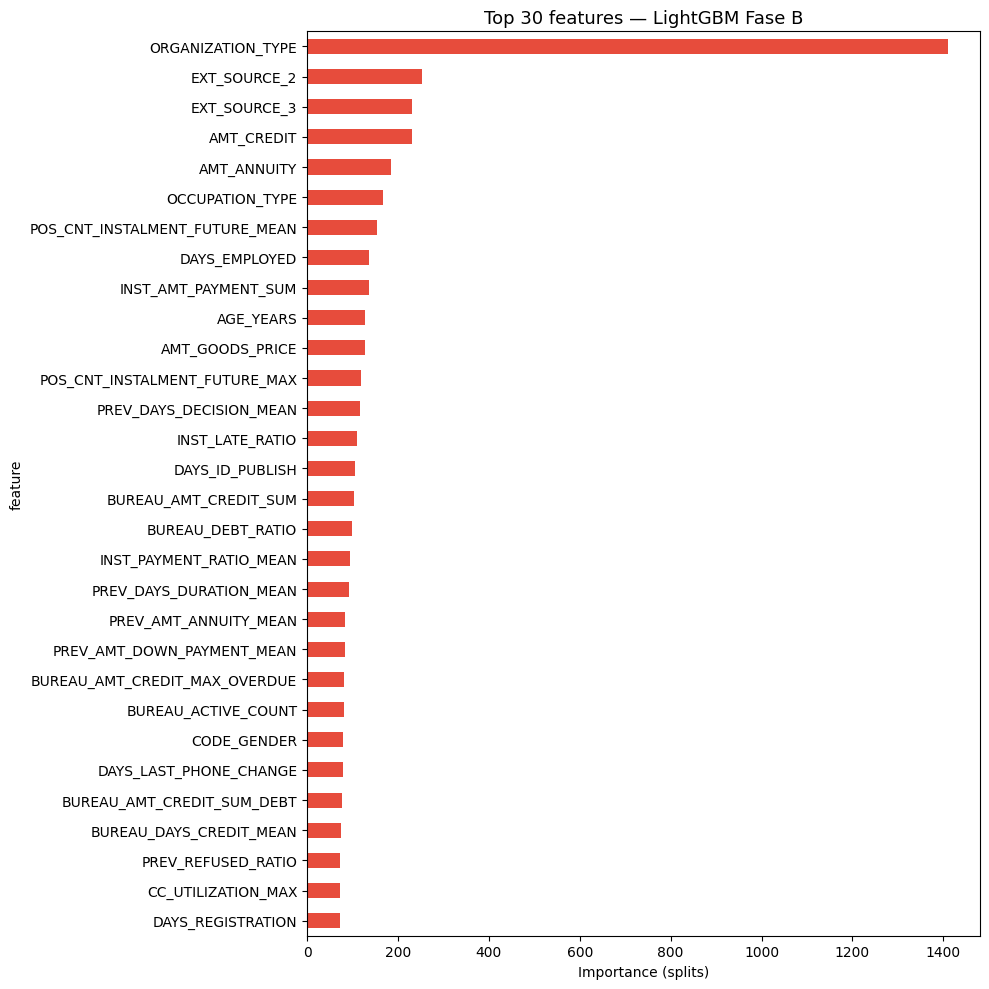

Top 15 features:
                       feature  importance
             ORGANIZATION_TYPE        1410
                  EXT_SOURCE_2         254
                  EXT_SOURCE_3         231
                    AMT_CREDIT         231
                   AMT_ANNUITY         184
               OCCUPATION_TYPE         167
POS_CNT_INSTALMENT_FUTURE_MEAN         154
                 DAYS_EMPLOYED         136
          INST_AMT_PAYMENT_SUM         136
                     AGE_YEARS         128
               AMT_GOODS_PRICE         127
 POS_CNT_INSTALMENT_FUTURE_MAX         119
       PREV_DAYS_DECISION_MEAN         116
               INST_LATE_RATIO         111
               DAYS_ID_PUBLISH         105


In [5]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
importance_df.head(30).sort_values('importance').plot(
    kind='barh', x='feature', y='importance',
    ax=ax, color='#e74c3c', legend=False
)
ax.set_title('Top 30 features — LightGBM Fase B', fontsize=13)
ax.set_xlabel('Importance (splits)')
plt.tight_layout()
plt.show()

print('Top 15 features:')
print(importance_df.head(15).to_string(index=False))